In [5]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [1]:
import os
import shutil
from pathlib import Path
import cv2
from sklearn.model_selection import train_test_split
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
from tensorflow.keras import regularizers
from tensorflow.keras.applications import EfficientNetB0, EfficientNetB3, DenseNet121, ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense, Dropout, BatchNormalization

np.random.seed(42)
tf.random.set_seed(42)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [6]:
data_dir = Path('/content/drive/MyDrive/Alzheimers /Data')
classes = ['Non Demented', 'Very mild Dementia', 'Mild Dementia', 'Moderate Dementia']


In [7]:
# Counting images per class

class_counts = {}
for cls in classes:
  class_path = data_dir/cls
  class_counts[cls] = len(list(class_path.glob('*.jpg')))
  print(f"{cls}: {class_counts[cls]} images")

Non Demented: 6975 images
Very mild Dementia: 3356 images
Mild Dementia: 5002 images
Moderate Dementia: 488 images


In [8]:
X_train_balanced = np.load("/content/drive/MyDrive/Alzheimers /Data/balanced_data/X_train_balanced.npy")
y_train_balanced = np.load("/content/drive/MyDrive/Alzheimers /Data/balanced_data/y_train_balanced.npy")
X_val = np.load("/content/drive/MyDrive/Alzheimers /Data/balanced_data/X_val.npy")
y_val = np.load("/content/drive/MyDrive/Alzheimers /Data/balanced_data/y_val.npy")
X_test = np.load("/content/drive/MyDrive/Alzheimers /Data/balanced_data/X_test.npy")
y_test = np.load("/content/drive/MyDrive/Alzheimers /Data/balanced_data/y_test.npy")

 Label: Moderate Dementia (Class 3)


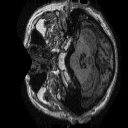


 Label: Very mild Dementia (Class 1)


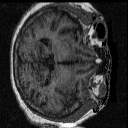


 Label: Moderate Dementia (Class 3)


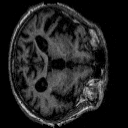


 Label: Very mild Dementia (Class 1)


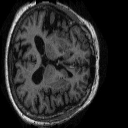


 Label: Moderate Dementia (Class 3)


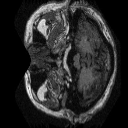

In [9]:
from PIL import Image

def display_images(X, y, classes, n=5):
  indices = np.random.choice(len(X), min(n, len(X)), replace=False)

  for i in indices:
    img = X[i]
    label_i = y[i]
    label_name = classes[label_i]

    pil_img = Image.fromarray((img*255).astype("uint8"))

    print(f" Label: {label_name} (Class {label_i})")
    display(pil_img)
    print()

display_images(X_train_balanced, y_train_balanced, classes, n=5)

In [10]:
import cv2

X_train_resized = np.empty((len(X_train_balanced), 224, 224, 3), dtype=np.float32)

for i, img in enumerate(X_train_balanced):
    img_uint8 = (img*255).astype(np.uint8)
    X_train_resized[i] = cv2.resize(img_uint8, (224, 224), interpolation=cv2.INTER_AREA) / 255.0

    if i%1000 == 0:
        print(f"Resized {i+1}/{len(X_train_balanced)} images")

del X_train_balanced
X_train_balanced = X_train_resized
print(f"{X_train_balanced.shape}")

Resized 1/10464 images
Resized 1001/10464 images
Resized 2001/10464 images
Resized 3001/10464 images
Resized 4001/10464 images
Resized 5001/10464 images
Resized 6001/10464 images
Resized 7001/10464 images
Resized 8001/10464 images
Resized 9001/10464 images
Resized 10001/10464 images
(10464, 224, 224, 3)


In [11]:
import cv2

X_val_resized = np.empty((len(X_val), 224, 224, 3), dtype=np.float32)

for i, img in enumerate(X_val):
    img_uint8 = (img*255).astype(np.uint8)
    X_val_resized[i] = cv2.resize(img_uint8, (224, 224), interpolation=cv2.INTER_AREA) / 255.0

    if i%1000 == 0:
        print(f"Resized {i+1}/{len(X_val)} images")

del X_val
X_val = X_val_resized
print(f"{X_val.shape}")

Resized 1/2035 images
Resized 1001/2035 images
Resized 2001/2035 images
(2035, 224, 224, 3)


In [12]:
import cv2

X_test_resized = np.empty((len(X_test), 224, 224, 3), dtype=np.float32)

for i, img in enumerate(X_test):
    img_uint8 = (img*255).astype(np.uint8)
    X_test_resized[i] = cv2.resize(img_uint8, (224, 224), interpolation=cv2.INTER_AREA) / 255.0

    if i%1000 == 0:
        print(f"Resized {i+1}/{len(X_test)} images")

del X_test
X_test = X_test_resized
print(f"{X_test.shape}")

Resized 1/2730 images
Resized 1001/2730 images
Resized 2001/2730 images
(2730, 224, 224, 3)


In [13]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train_balanced.reshape(-1, 1))
y_val_onehot = encoder.transform(y_val.reshape(-1, 1))
y_test_onehot = encoder.transform(y_test.reshape(-1, 1))

print(f"\nOne-hot encoded shapes:")
print(f"  y_train: {y_train_onehot.shape}")
print(f"  y_val: {y_val_onehot.shape}")
print(f"  y_test: {y_test_onehot.shape}")


One-hot encoded shapes:
  y_train: (10464, 4)
  y_val: (2035, 4)
  y_test: (2730, 4)


In [ ]:
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y_balanced, random_state=42)

In [14]:
print(X_train_balanced.shape)
print(X_val.shape)
print(X_test.shape)

(10464, 224, 224, 3)
(2035, 224, 224, 3)
(2730, 224, 224, 3)


In [15]:
# BUILD TRANSFER LEARNING MODEL (Functional API)

from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomFlip("vertical"),
    layers.RandomRotation(0.1),  # ±10 degrees (5% of 180)
    layers.RandomZoom(0.15),  # ±10% zoom
    layers.RandomTranslation(0.1, 0.1),  # ±5% shift
    layers.RandomContrast(0.2)  # ±10% contrast

], name='data_augmentation')

def build_transfer_model(model_name='EfficientNetB0', input_shape=(224, 224, 3), num_classes=4):
    """
    Build transfer learning model using Keras Functional API

    Args:
        model_name: 'EfficientNetB0', 'EfficientNetB3', 'DenseNet121', 'ResNet50'
        input_shape: Input image shape (height, width, channels)
        num_classes: Number of output classes
    """

    print(f"BUILDING TRANSFER LEARNING MODEL: {model_name}")


    # Input layer
    inputs = Input(shape=input_shape, name='input_layer')

    x = layers.Rescaling(scale=255.0)(inputs)

    x = data_augmentation(x)

    # Select pretrained backbone
    if model_name == 'EfficientNetB0':
        base_model = EfficientNetB0(include_top=False, weights='imagenet', input_shape=input_shape)
        print("✓ Loaded EfficientNetB0 with ImageNet weights")
    elif model_name == 'EfficientNetB3':
        base_model = EfficientNetB3(include_top=False, weights='imagenet', input_tensor=inputs)
        print("✓ Loaded EfficientNetB3 with ImageNet weights")
    elif model_name == 'DenseNet121':
        base_model = DenseNet121(include_top=False, weights='imagenet', input_tensor=inputs)
        print("✓ Loaded DenseNet121 with ImageNet weights")
    elif model_name == 'ResNet50':
        base_model = ResNet50(include_top=False, weights='imagenet', input_tensor=inputs)
        print("✓ Loaded ResNet50 with ImageNet weights")
    else:
        raise ValueError(f"Unknown model: {model_name}")

    # Freeze base model for Phase 1
    base_model.trainable = False

    # Get output from base model
    x = base_model(x, training=False)

    # Add custom classification head
    x = GlobalAveragePooling2D(name='global_avg_pool')(x)
    x = Dropout(0.3, name="dropout_0")(x)
    x = Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.005), name='dense_1')(x)
    x = BatchNormalization(name='batch_norm_1')(x)
    x = Dropout(0.3, name='dropout_1')(x)
    x = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(0.005), name='dense_2')(x)
    x = BatchNormalization(name='batch_norm_2')(x)
    x = Dropout(0.3, name='dropout_2')(x)
    outputs = Dense(num_classes, activation='softmax', name='output')(x)

    # Create model
    model = Model(inputs=inputs, outputs=outputs, name=f'{model_name}_balanced')

    print(f"✓ Custom classification head added")
    print(f"✓ Base model frozen: {not base_model.trainable}")
    print(f"✓ Total layers: {len(model.layers)}")
    print(f"✓ Trainable params (top layers only): {model.count_params() - base_model.count_params():,}")
    print(f"{'='*70}\n")

    return model, base_model


model, base_model = build_transfer_model('EfficientNetB0', input_shape=(224, 224, 3), num_classes=4)
# model, base_model = build_transfer_model('EfficientNetB3', input_shape=(128, 128, 3), num_classes=4)
# model, base_model = build_transfer_model('DenseNet121', input_shape=(128, 128, 3), num_classes=4)
# model, base_model = build_transfer_model('ResNet50', input_shape=(128, 128, 3), num_classes=4)

# Display model summary
model.summary()

BUILDING TRANSFER LEARNING MODEL: EfficientNetB0
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✓ Loaded EfficientNetB0 with ImageNet weights
✓ Custom classification head added
✓ Base model frozen: True
✓ Total layers: 13
✓ Trainable params (top layers only): 362,884



Model: "EfficientNetB0_balanced"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_0 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_1                    │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_norm_2                    │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,412,455 (16.83 MB)

 Trainable params: 362,116 (1.38 MB)

 Non-trainable params: 4,050,339 (15.45 MB)

In [16]:
from datetime import datetime

timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
model_name = model.name.replace('_transfer', '')
save_dir = f'/content/drive/MyDrive/Alzheimers /saved_models/transfer_{model_name}_{timestamp}'
os.makedirs(save_dir, exist_ok=True)

In [17]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

phase1_model_path = os.path.join(save_dir, 'phase1_best_model.keras')
phase1_weights_path = os.path.join(save_dir, 'phase1_best_weights.weights.h5')

checkpoint_phase1_model = ModelCheckpoint(
    filepath=phase1_model_path,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

checkpoint_phase1_weights = ModelCheckpoint(
    filepath=phase1_weights_path,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

early_stop_phase1 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_phase1 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-7,
    verbose=1
)

callbacks_phase1 = [
    checkpoint_phase1_model,
    checkpoint_phase1_weights,
    early_stop_phase1,
    reduce_lr_phase1
]

print("callbakcs configured {frozen backbone training}")

callbakcs configured {frozen backbone training}


In [18]:
phase2_model_path = os.path.join(save_dir, 'phase2_best_model.keras')
phase2_weights_path = os.path.join(save_dir, 'phase2_best_weights.weights.h5')

checkpoint_phase2_model = ModelCheckpoint(
    filepath=phase2_model_path,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    save_weights_only=False,
    verbose=1
)

checkpoint_phase2_weights = ModelCheckpoint(
    filepath=phase2_weights_path,
    monitor='val_accuracy',
    mode='max',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

early_stop_phase2 = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr_phase2 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=4,
    min_lr=1e-7,
    verbose=1
)

callbacks_phase2 = [
    checkpoint_phase2_model,
    checkpoint_phase2_weights,
    early_stop_phase2,
    reduce_lr_phase2
]

print("callbakcs configured {frozen backbone training}")

callbakcs configured {frozen backbone training}


In [19]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# Train Phase 1
history_phase1 = model.fit(
    X_train_balanced, y_train_onehot,
    batch_size=16,
    epochs=15,
    validation_data=(X_val, y_val_onehot),
    callbacks=callbacks_phase1,
    verbose=1)

Epoch 1/15
654/654 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4203 - loss: 4.0653
Epoch 1: val_accuracy improved from -inf to 0.50123, saving model to /content/drive/MyDrive/Alzheimers /saved_models/transfer_EfficientNetB0_balanced_20251202_194150/phase1_best_model.keras

Epoch 1: val_accuracy improved from -inf to 0.50123, saving model to /content/drive/MyDrive/Alzheimers /saved_models/transfer_EfficientNetB0_balanced_20251202_194150/phase1_best_weights.weights.h5
654/654 ━━━━━━━━━━━━━━━━━━━━ 54s 61ms/step - accuracy: 0.4204 - loss: 4.0644 - val_accuracy: 0.5012 - val_loss: 2.4196 - learning_rate: 0.0010
Epoch 2/15
653/654 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5411 - loss: 2.2032
Epoch 2: val_accuracy improved from 0.50123 to 0.52973, saving model to /content/drive/MyDrive/Alzheimers /saved_models/transfer_EfficientNetB0_balanced_20251202_194150/phase1_best_model.keras

Epoch 2: val_accuracy improved from 0.50123 to 0.52973, saving model to /content/drive/MyDrive/Alzhei

In [20]:
base_model.trainable = True

# Freeze all but the last 30 layers (EfficientNetB0 has ~237 layers)
for layer in base_model.layers[:-40]:
    layer.trainable = False

# Verify
trainable_count = sum([1 for layer in base_model.layers if layer.trainable])
print(f"Unfreezing top {trainable_count} layers out of {len(base_model.layers)}")

Unfreezing top 40 layers out of 238


In [21]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

# Train Phase 2
history_phase2 = model.fit(
    X_train_balanced, y_train_onehot,
    batch_size=32,  # Smaller batch for fine-tuning
    epochs=25,
    validation_data=(X_val, y_val_onehot),
    callbacks=callbacks_phase2,
    verbose=1
)

Epoch 1/25
327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - accuracy: 0.5236 - loss: 1.2996
Epoch 1: val_accuracy improved from -inf to 0.54005, saving model to /content/drive/MyDrive/Alzheimers /saved_models/transfer_EfficientNetB0_balanced_20251202_194150/phase2_best_model.keras

Epoch 1: val_accuracy improved from -inf to 0.54005, saving model to /content/drive/MyDrive/Alzheimers /saved_models/transfer_EfficientNetB0_balanced_20251202_194150/phase2_best_weights.weights.h5
327/327 ━━━━━━━━━━━━━━━━━━━━ 59s 132ms/step - accuracy: 0.5237 - loss: 1.2995 - val_accuracy: 0.5400 - val_loss: 1.3084 - learning_rate: 1.0000e-05
Epoch 2/25
327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step - accuracy: 0.5747 - loss: 1.2094
Epoch 2: val_accuracy improved from 0.54005 to 0.56020, saving model to /content/drive/MyDrive/Alzheimers /saved_models/transfer_EfficientNetB0_balanced_20251202_194150/phase2_best_model.keras

Epoch 2: val_accuracy improved from 0.54005 to 0.56020, saving model to /content/drive/MyDrive/A

In [22]:
def plot_transfer_learning_history(hist1, hist2, save_dir):
    """Plot combined training history from both phases"""

    print(f"\n{'='*70}")
    print("GENERATING TRAINING HISTORY PLOTS")
    print(f"{'='*70}")

    fig, axes = plt.subplots(1, 2, figsize=(18, 6))

    # Combine metrics from both phases
    phase1_epochs = len(hist1.history['accuracy'])
    total_epochs = phase1_epochs + len(hist2.history['accuracy'])

    train_acc = hist1.history['accuracy'] + hist2.history['accuracy']
    val_acc = hist1.history['val_accuracy'] + hist2.history['val_accuracy']
    train_loss = hist1.history['loss'] + hist2.history['loss']
    val_loss = hist1.history['val_loss'] + hist2.history['val_loss']

    epochs = range(1, total_epochs + 1)

    # Plot 1: Accuracy
    axes[0].plot(epochs, train_acc, 'b-', label='Train Accuracy', linewidth=2, alpha=0.8)
    axes[0].plot(epochs, val_acc, 'r-', label='Val Accuracy', linewidth=2, alpha=0.8)
    axes[0].axvline(x=phase1_epochs, color='green', linestyle='--',
                    label='Phase 2 Start (Unfreeze)', linewidth=2.5)
    axes[0].set_title('Transfer Learning - Model Accuracy', fontsize=15, fontweight='bold', pad=15)
    axes[0].set_xlabel('Epoch', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Accuracy', fontsize=13, fontweight='bold')
    axes[0].legend(fontsize=11, loc='lower right')
    axes[0].grid(True, alpha=0.3)
    axes[0].set_ylim([0, 1])

    # Annotate phases
    axes[0].text(phase1_epochs/2, 0.95, 'Phase 1\n(Frozen)',
                ha='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    axes[0].text(phase1_epochs + (total_epochs-phase1_epochs)/2, 0.95, 'Phase 2\n(Fine-tune)',
                ha='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

    # Plot 2: Loss
    axes[1].plot(epochs, train_loss, 'b-', label='Train Loss', linewidth=2, alpha=0.8)
    axes[1].plot(epochs, val_loss, 'r-', label='Val Loss', linewidth=2, alpha=0.8)
    axes[1].axvline(x=phase1_epochs, color='green', linestyle='--',
                    label='Phase 2 Start (Unfreeze)', linewidth=2.5)
    axes[1].set_title('Transfer Learning - Model Loss', fontsize=15, fontweight='bold', pad=15)
    axes[1].set_xlabel('Epoch', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Loss', fontsize=13, fontweight='bold')
    axes[1].legend(fontsize=11, loc='upper right')
    axes[1].grid(True, alpha=0.3)

    # Annotate phases
    max_loss = max(max(train_loss), max(val_loss))
    axes[1].text(phase1_epochs/2, max_loss*0.95, 'Phase 1\n(Frozen)',
                ha='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    axes[1].text(phase1_epochs + (total_epochs-phase1_epochs)/2, max_loss*0.95, 'Phase 2\n(Fine-tune)',
                ha='center', fontsize=11, bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

    plt.tight_layout()

    # Save
    save_path = os.path.join(save_dir, 'transfer_learning_history.png')
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✓ Training history plot saved: {save_path}")

    print(f"Training Summary:")
    print(f"  Phase 1 (Frozen): {phase1_epochs} epochs")
    print(f"  Phase 2 (Fine-tune): {len(hist2.history['accuracy'])} epochs")
    print(f"  Total: {total_epochs} epochs")
    print(f"  Final Train Accuracy: {train_acc[-1]:.4f}")
    print(f"  Final Val Accuracy: {val_acc[-1]:.4f}")
    print(f"  Best Val Accuracy: {max(val_acc):.4f} (Epoch {val_acc.index(max(val_acc))+1})")



GENERATING TRAINING HISTORY PLOTS


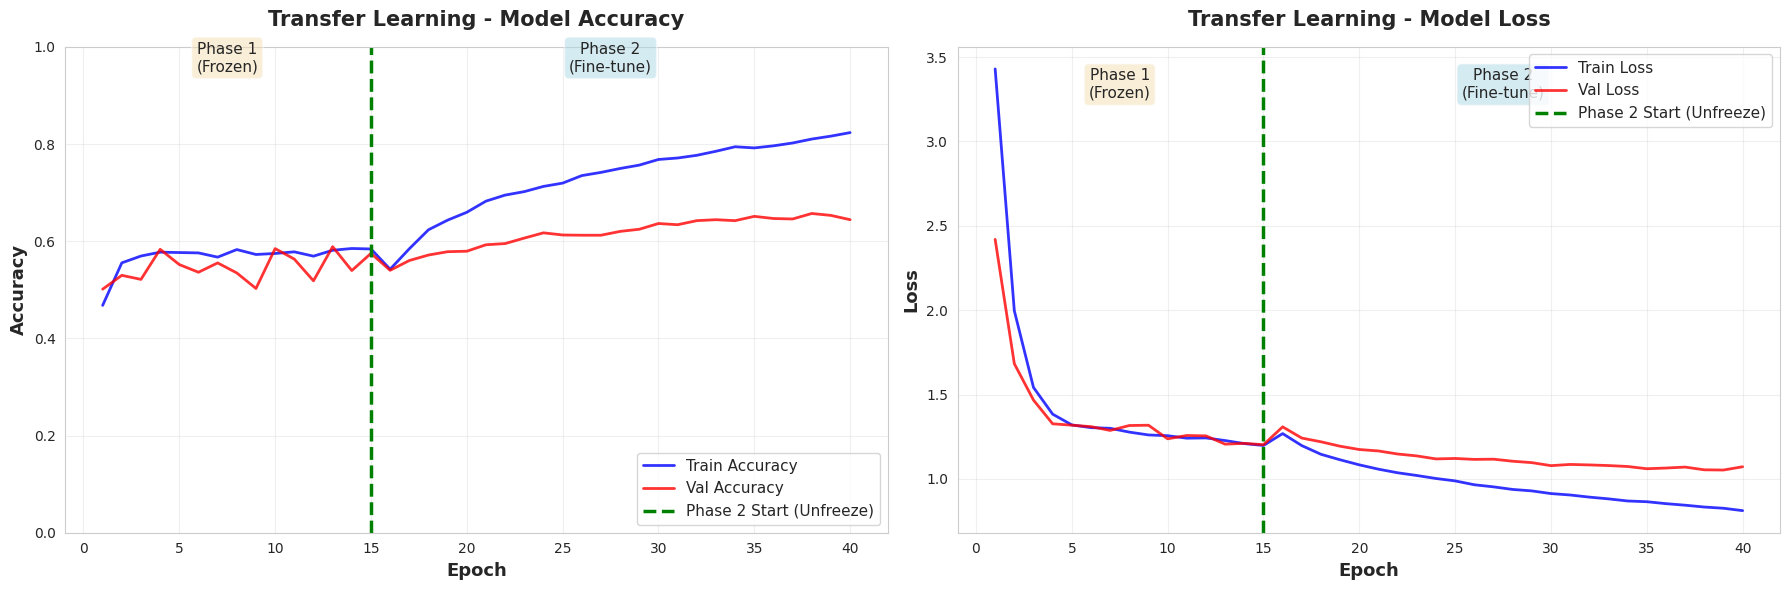

✓ Training history plot saved: /content/drive/MyDrive/Alzheimers /saved_models/transfer_EfficientNetB0_balanced_20251202_194150/transfer_learning_history.png
Training Summary:
  Phase 1 (Frozen): 15 epochs
  Phase 2 (Fine-tune): 25 epochs
  Total: 40 epochs
  Final Train Accuracy: 0.8235
  Final Val Accuracy: 0.6442
  Best Val Accuracy: 0.6570 (Epoch 38)


In [23]:
plot_transfer_learning_history(history_phase1, history_phase2, save_dir)

In [24]:
print("\nGenerating predictions on test set...")
y_pred_proba = model.predict(X_test, verbose=1)
y_pred = np.argmax(y_pred_proba, axis=1)
y_true = np.argmax(y_test_onehot, axis=1)

print(f"Generated predictions for {len(y_true)} test samples")


Generating predictions on test set...
86/86 ━━━━━━━━━━━━━━━━━━━━ 11s 106ms/step
Generated predictions for 2730 test samples


In [25]:
test_accuracy = np.mean(y_true == y_pred)

print(f"TEST SET ACCURACY: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

TEST SET ACCURACY: 0.6579 (65.79%)


In [26]:
from sklearn.metrics import classification_report

print("CLASSIFICATION REPORT")

report = classification_report(
    y_true,
    y_pred,
    target_names=classes,
    digits=4
)
print(report)

CLASSIFICATION REPORT
                    precision    recall  f1-score   support

      Non Demented     0.7253    0.8327    0.7753      1297
Very mild Dementia     0.3846    0.2606    0.3107       518
     Mild Dementia     0.6732    0.6350    0.6535       915
 Moderate Dementia     0.0000    0.0000    0.0000         0

          accuracy                         0.6579      2730
         macro avg     0.4458    0.4321    0.4349      2730
      weighted avg     0.6432    0.6579    0.6463      2730



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [27]:
from sklearn.metrics import precision_recall_fscore_support


precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, average=None
)

print("PER-CLASS PERFORMANCE BREAKDOWN")

print(f"{'Class':<20} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'Support'}")
print("-"*70)

for i, name in enumerate(classes):
    print(f"{name:<20} {precision[i]:<12.4f} {recall[i]:<12.4f} "
          f"{f1[i]:<12.4f} {int(support[i])}")

PER-CLASS PERFORMANCE BREAKDOWN
Class                Precision    Recall       F1-Score     Support
----------------------------------------------------------------------
Non Demented         0.7253       0.8327       0.7753       1297
Very mild Dementia   0.3846       0.2606       0.3107       518
Mild Dementia        0.6732       0.6350       0.6535       915
Moderate Dementia    0.0000       0.0000       0.0000       0


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


/tmp/ipython-input-2484488366.py:6: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


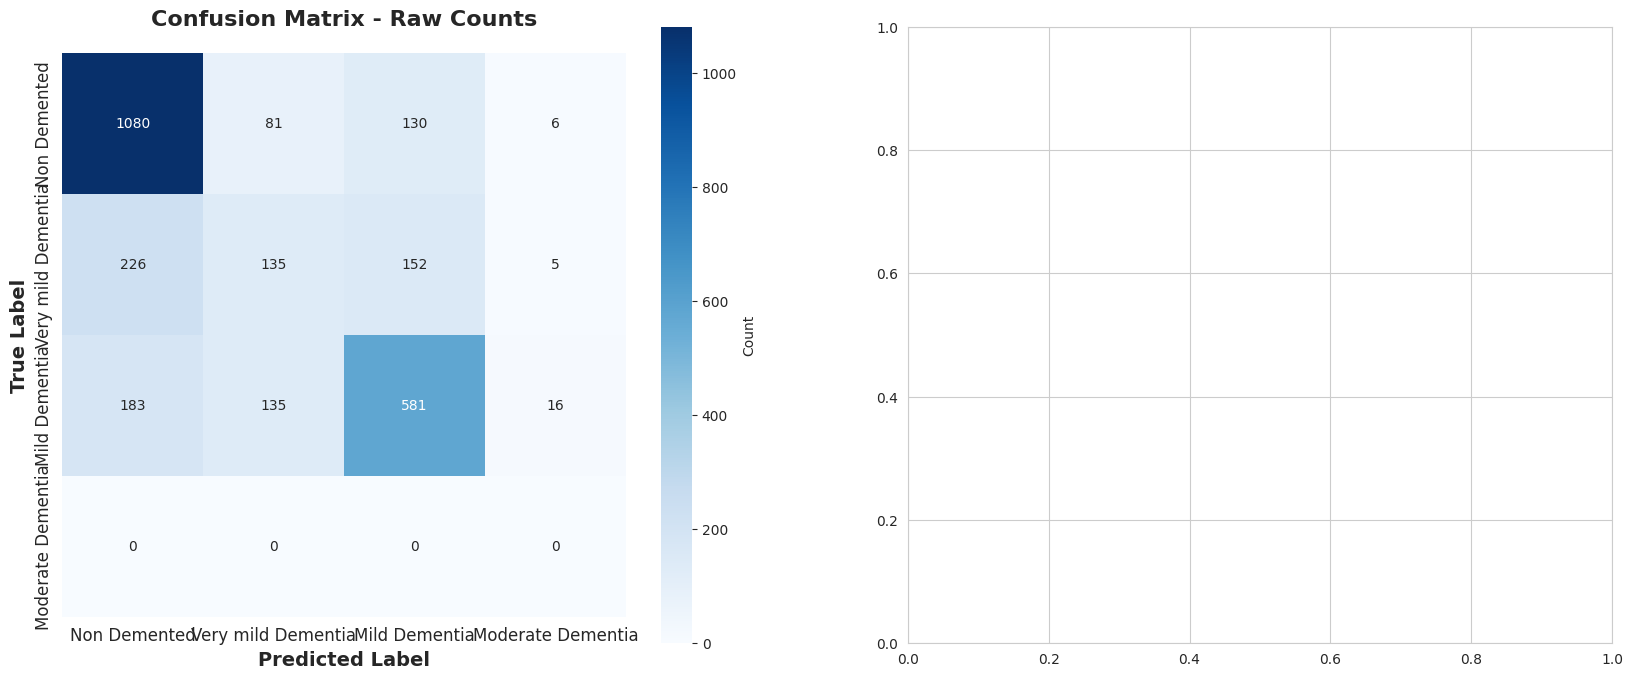

In [28]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Plot 1: Raw counts
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=classes,
    yticklabels=classes,
    cbar_kws={'label': 'Count'},
    ax=axes[0],
    square=True
)
axes[0].set_title('Confusion Matrix - Raw Counts', fontsize=16, fontweight='bold', pad=20)
axes[0].set_ylabel('True Label', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
axes[0].tick_params(labelsize=12)